# ***Task 4 — End-to-End Smartphone Price Prediction Project***

## ***Project Title***

#### ***Smartphone Price Prediction — End-to-End Data Science Project***

## ***Project Objective***

- The objective of this project is to analyze a Smartphone Dataset, prepare and clean the data, perform Exploratory Data Analysis (EDA), build a baseline machine learning model, evaluate its performance, and summarize the findings and limitations.

- The project combines all the previous tasks into one complete workflow.

## ***Problem Statement***

- Smartphone prices vary significantly depending on their specifications and features, such as RAM, storage, battery capacity, camera specifications, display size, and user/expert ratings.

- The objective of this project is to investigate the relationship between smartphone specifications and price and build a baseline machine learning model that can predict the price of a smartphone using selected numerical features.

## ***Project Workflow***

## ***Technologies Used***

#### ***Import Libraries***

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

#### ***Load Dataset***

In [2]:
df = pd.read_csv("smartphones_prepared.csv")
print("Dataset Shape:", df.shape, '\n')
df.head()

Dataset Shape: (2256, 14) 



,model_name,price,expert_rating,user_rating,processor,rear_cameras,front_cameras,display,ram_internal_memory,battery,operating_system,additional_features,review,review_link
0,vivo V40,"34,999",7.8,4.5 ★\n1.3L Ratings,Snapdragon 7 Gen 3 Octa core,50+50 MP Rear Camera,50 MP Front Camera,6.78″ (17.22 cm) 120Hz AMOLED Display,8 GB RAM | 128 GB Storage,5500 mAh | 80W Fast Charging,Android v14 OS,5G | Fingerprint Sensor,....Read Full Review,https://www.mysmartprice.com/gear/mobiles/mobi...
1,OPPO K12x,"12,999",7.8,4.5 ★\n1.3L Ratings,MediaTek Dimensity 6300 Octa core,32+2 MP Rear Camera,8 MP Front Camera,6.67″ (16.94 cm) 120Hz LCD Display,6 GB RAM | 128 GB Storage,5100 mAh | 45W Fast Charging,Android v14 OS,5G | Fingerprint Sensor,....Read Full Review,https://www.mysmartprice.com/gear/mobiles/mobi...
2,vivo V40 Pro,"49,999",8.2,4.5 ★\n1.3L Ratings,MediaTek Dimensity 9200 Plus Octa core,50+50+50 MP Rear Camera,50 MP Front Camera,6.78″ (17.22 cm) 120Hz AMOLED Display,8 GB RAM | 256 GB Storage,5500 mAh | 80W Fast Charging,Android v14 OS,5G | Fingerprint Sensor,"The Vivo V40 Pro shines with its cameras, perf...",https://www.mysmartprice.com/gear/mobiles/mobi...
3,Motorola Edge 50 Fusion,"24,879",8.1,4.5 ★\n16.9K Ratings,Snapdragon 7s Gen 2 Octa core,50+13 MP Rear Camera,32 MP Front Camera,6.67″ (16.94 cm) 144Hz P-OLED Display,8 GB RAM | 128 GB Storage,5000 mAh | 68W Fast Charging,Android v14 OS,5G | NFC | Fingerprint Sensor,Moto Edge 50 Fusion has a premium design and s...,https://www.mysmartprice.com/gear/mobiles/mobi...
4,Samsung Galaxy M35 5G,"19,999",7.8,4.3 ★\n383 Ratings,Samsung Exynos 1380 Octa core,50+8+2 MP Rear Camera,13 MP Front Camera,6.6″ (16.76 cm) 120Hz Super AMOLED Display,6 GB RAM | 128 GB Storage,6000 mAh | 25W Fast Charging,Android v14 OS,5G | NFC | Fingerprint Sensor,....Read Full Review,https://www.mysmartprice.com/gear/mobiles/mobi...


#### ***Understand the Dataset***

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2256 entries, 0 to 2255
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_name           2256 non-null   object 
 1   price                2256 non-null   object 
 2   expert_rating        2256 non-null   float64
 3   user_rating          2256 non-null   object 
 4   processor            2256 non-null   object 
 5   rear_cameras         2256 non-null   object 
 6   front_cameras        2256 non-null   object 
 7   display              2256 non-null   object 
 8   ram_internal_memory  2256 non-null   object 
 9   battery              2256 non-null   object 
 10  operating_system     2256 non-null   object 
 11  additional_features  2256 non-null   object 
 12  review               2256 non-null   object 
 13  review_link          2256 non-null   object 
dtypes: float64(1), object(13)
memory usage: 246.9+ KB


#### ***Check Columns***

In [4]:
df.columns

Index(['model_name', 'price', 'expert_rating', 'user_rating', 'processor',
       'rear_cameras', 'front_cameras', 'display', 'ram_internal_memory',
       'battery', 'operating_system', 'additional_features', 'review',
       'review_link'],
      dtype='object')

#### ***Check Missing Value***

In [5]:
df.isnull().sum()

model_name             0
price                  0
expert_rating          0
user_rating            0
processor              0
rear_cameras           0
front_cameras          0
display                0
ram_internal_memory    0
battery                0
operating_system       0
additional_features    0
review                 0
review_link            0
dtype: int64

#### ***Check Duplicate Value***

In [6]:
df.duplicated().sum()

np.int64(0)

## ***Data Preparation***

- Task 1 focused on preparing the raw Smartphone Dataset.
- The preparation process included:
    - Loading the dataset
    - Checking dataset structure
    - Identifying missing values
    - Detecting duplicate records
    - Removing duplicate records
    - Separating numerical and categorical columns
    - Handling numerical missing values using median
    - Handling categorical missing values using mode
    - Performing basic statistical analysis
    - Performing final data quality checks
    - Exporting the prepared dataset

* The prepared dataset is then used for EDA and modeling.

## ***Descriptive Statistics**

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
expert_rating,2256.0,7.799911,0.474213,3.5,7.8,7.8,8.0,9.5


- This provides statistics such as:
    - Count
    - Mean
    - Standard deviation
    - Minimum
    - Maximum
    - Quartiles

* for numerical columns.

## ***Feature Engineering***

- Many smartphone specifications are stored as text.
- For machine learning, we need to convert important information into numerical features.

#### ***Convert Price***

In [8]:
df["price_numeric"] = (df["price"].astype(str)
    .str.replace(",", "", regex = False)
    .str.replace("₹", "", regex = False)
    .str.extract(r"(\d+(?:\.\d+)?)", expand = False)
)

df["price_numeric"] = pd.to_numeric(df["price_numeric"], errors="coerce")

In [9]:
df[["price", "price_numeric"]].head()

,price,price_numeric
0,"34,999",34999
1,"12,999",12999
2,"49,999",49999
3,"24,879",24879
4,"19,999",19999


#### ***Extract RAM***

- The ram_internal_memory column contains both RAM and storage information.

In [10]:
ram_text = df["ram_internal_memory"].astype(str)

ram_gb = ram_text.str.extract(r"(\d+(?:\.\d+)?)\s*GB\s*RAM", expand = False)
ram_mb = ram_text.str.extract(r"(\d+(?:\.\d+)?)\s*MB\s*RAM", expand = False)

ram_gb = pd.to_numeric(ram_gb, errors = "coerce")
ram_mb = pd.to_numeric(ram_mb, errors = "coerce")

df["ram_gb"] = ram_gb

df.loc[df["ram_gb"].isna(), "ram_gb"] = ram_mb[df["ram_gb"].isna()] / 1024

#### ***Extract Storage***

In [11]:
storage_text = df["ram_internal_memory"].astype(str)

storage_gb = storage_text.str.extract(r"(\d+(?:\.\d+)?)\s*GB\s*Storage", expand = False)
storage_tb = storage_text.str.extract(r"(\d+(?:\.\d+)?)\s*TB\s*Storage", expand = False)
storage_mb = storage_text.str.extract(r"(\d+(?:\.\d+)?)\s*MB\s*Storage", expand = False)

storage_gb = pd.to_numeric(storage_gb, errors="coerce")
storage_tb = pd.to_numeric(storage_tb, errors="coerce")
storage_mb = pd.to_numeric(storage_mb, errors="coerce")

df["storage_gb"] = storage_gb

df.loc[df["storage_gb"].isna(), "storage_gb"] = storage_tb[df["storage_gb"].isna()] * 1024
df.loc[df["storage_gb"].isna(), "storage_gb"] = storage_mb[df["storage_gb"].isna()] / 1024

#### ***Convert Battery***

In [12]:
df["battery_mAh"] = (df["battery"].astype(str).str.extract(r"(\d+(?:\.\d+)?)", expand = False))
df["battery_mAh"] = pd.to_numeric(df["battery_mAh"], errors = "coerce")

#### ***Convert Rear Camera***

In [13]:
df["rear_camera_mp"] = (df["rear_cameras"].astype(str).str.extract(r"(\d+(?:\.\d+)?)", expand = False))
df["rear_camera_mp"] = pd.to_numeric(df["rear_camera_mp"], errors = "coerce")

#### ***Convert Front Camera***

In [14]:
df["front_camera_mp"] = (df["front_cameras"].astype(str).str.extract(r"(\d+(?:\.\d+)?)", expand = False))
df["front_camera_mp"] = pd.to_numeric(df["front_camera_mp"], errors = "coerce")

#### ***Convert Display Size***

In [15]:
df["display_size"] = (df["display"].astype(str).str.extract(r"(\d+(?:\.\d+)?)", expand = False))
df["display_size"] = pd.to_numeric(df["display_size"], errors = "coerce")

#### ***Convert User Rating***

In [16]:
df["user_rating_numeric"] = (df["user_rating"].astype(str).str.extract(r"(\d+(?:\.\d+)?)", expand = False))
df["user_rating_numeric"] = pd.to_numeric(df["user_rating_numeric"], errors = "coerce")

## ***Check Engineered Features***

In [17]:
feature_columns = [
    "expert_rating",
    "user_rating_numeric",
    "ram_gb",
    "storage_gb",
    "battery_mAh",
    "rear_camera_mp",
    "front_camera_mp",
    "display_size"
]

df[feature_columns + ["price_numeric"]].head()

,expert_rating,user_rating_numeric,ram_gb,storage_gb,battery_mAh,rear_camera_mp,front_camera_mp,display_size,price_numeric
0,7.8,4.5,8.0,128.0,5500,50.0,50.0,6.78,34999
1,7.8,4.5,6.0,128.0,5100,32.0,8.0,6.67,12999
2,8.2,4.5,8.0,256.0,5500,50.0,50.0,6.78,49999
3,8.1,4.5,8.0,128.0,5000,50.0,32.0,6.67,24879
4,7.8,4.3,6.0,128.0,6000,50.0,13.0,6.60,19999


In [18]:
df[feature_columns + ["price_numeric"]].isnull().sum()

expert_rating          0
user_rating_numeric    0
ram_gb                 6
storage_gb             0
battery_mAh            0
rear_camera_mp         0
front_camera_mp        0
display_size           1
price_numeric          0
dtype: int64

#### ***Handle Missing Values***

In [19]:
for column in feature_columns:
    df[column] = df[column].fillna(df[column].median())

df['price_numeric'] = df['price_numeric'].fillna(df['price_numeric'].median())
print('Total Missing Values:', df[feature_columns + ['price_numeric']].isnull().sum().sum())

Total Missing Values: 0


## ***Exploratory Data Analysis***

- Now we combine the EDA performed in Task 2.

#### ***Smartphone Price Distribution***

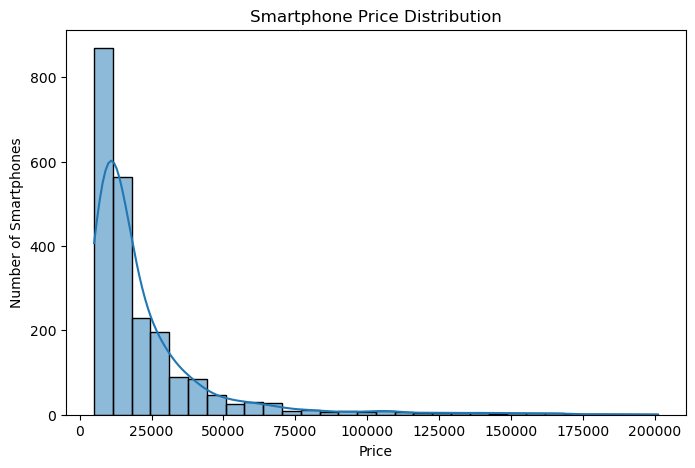

In [20]:
plt.figure(figsize = (8, 5))
sns.histplot(df['price_numeric'], bins = 30, kde = True)
plt.title('Smartphone Price Distribution')
plt.xlabel('Price')
plt.ylabel('Number of Smartphones')
plt.show()

#### ***Price Box Plot***

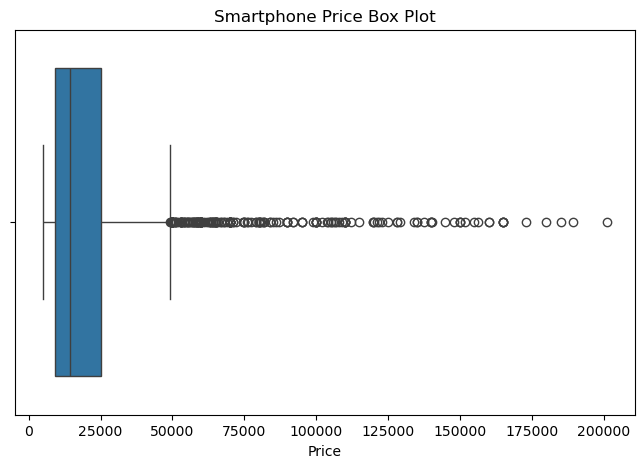

In [21]:
plt.figure(figsize = (8, 5))
sns.boxplot(x = df['price_numeric'])
plt.title('Smartphone Price Box Plot')
plt.xlabel('Price')
plt.show()

#### ***Expert Rating Distribution***

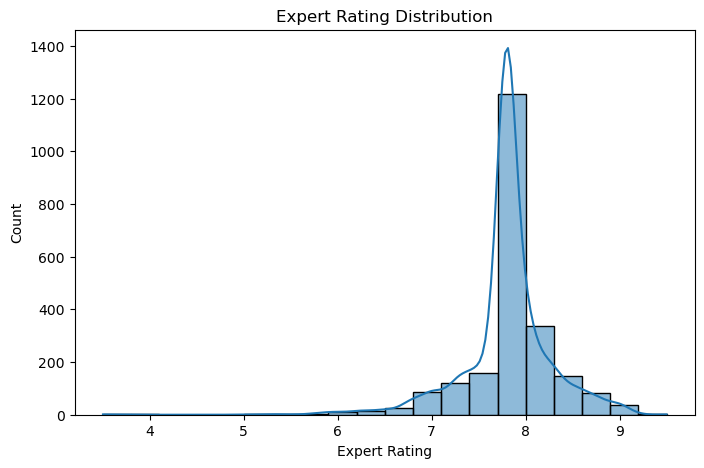

In [22]:
plt.figure(figsize = (8, 5))
sns.histplot(df['expert_rating'], bins = 20, kde = True)
plt.title('Expert Rating Distribution')
plt.xlabel('Expert Rating')
plt.ylabel('Count')
plt.show()

#### ***User Rating Distribution***

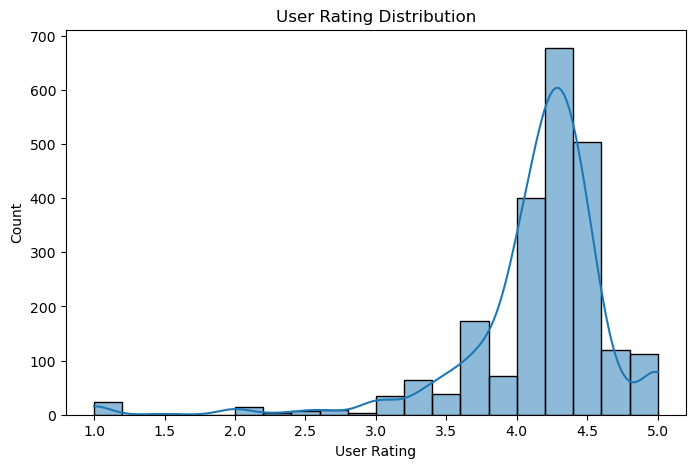

In [23]:
plt.figure(figsize = (8, 5))
sns.histplot(df['user_rating_numeric'], bins = 20, kde = True)
plt.title('User Rating Distribution')
plt.xlabel('User Rating')
plt.ylabel('Count')
plt.show()

#### ***RAM Distribution***

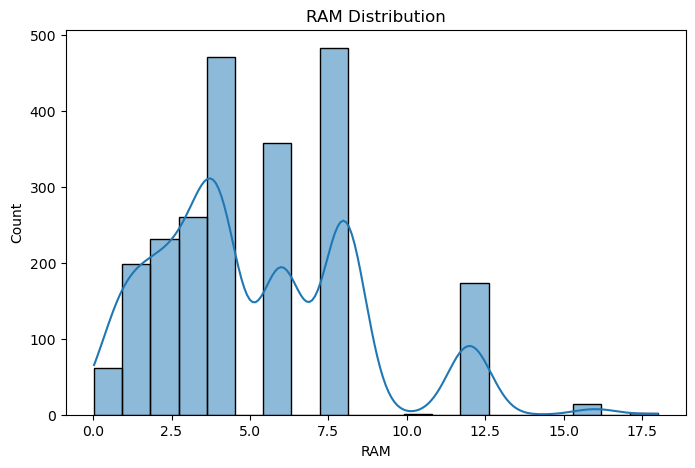

In [24]:
plt.figure(figsize = (8, 5))
sns.histplot(df['ram_gb'], bins = 20, kde = True)
plt.title('RAM Distribution')
plt.xlabel('RAM')
plt.ylabel('Count')
plt.show()

#### ***Storage Distribution***

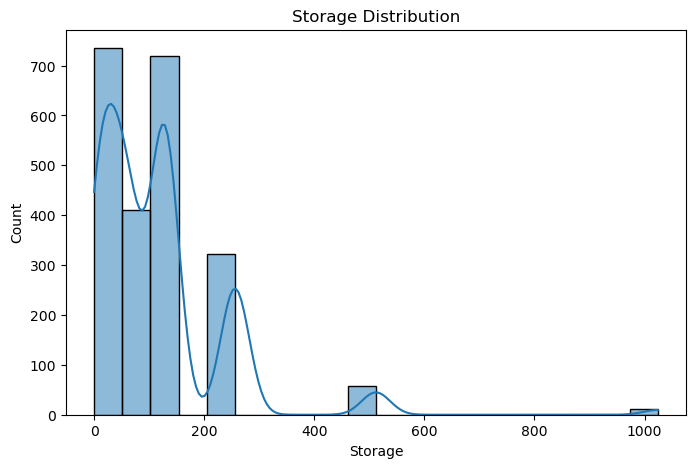

In [25]:
plt.figure(figsize = (8, 5))
sns.histplot(df['storage_gb'], bins = 20, kde = True)
plt.title('Storage Distribution')
plt.xlabel('Storage')
plt.ylabel('Count')
plt.show()

#### ***Battery Distribution***

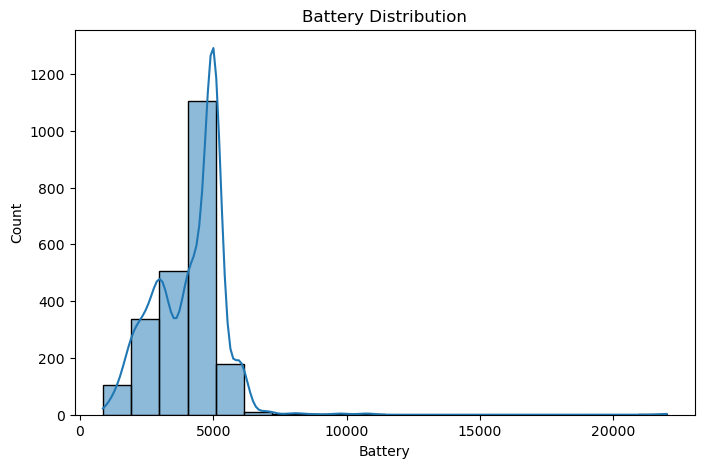

In [26]:
plt.figure(figsize = (8, 5))
sns.histplot(df['battery_mAh'], bins = 20, kde = True)
plt.title('Battery Distribution')
plt.xlabel('Battery')
plt.ylabel('Count')
plt.show()

#### ***Smartphone Price vs RAM***

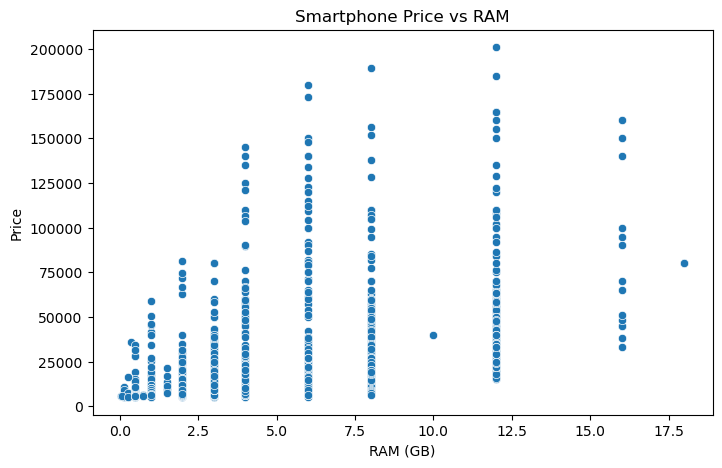

In [27]:
plt.figure(figsize = (8, 5))
sns.scatterplot(data = df, x = 'ram_gb', y = 'price_numeric')
plt.title('Smartphone Price vs RAM')
plt.xlabel('RAM (GB)')
plt.ylabel('Price')
plt.show()

#### ***Smartphone Price vs Storage***

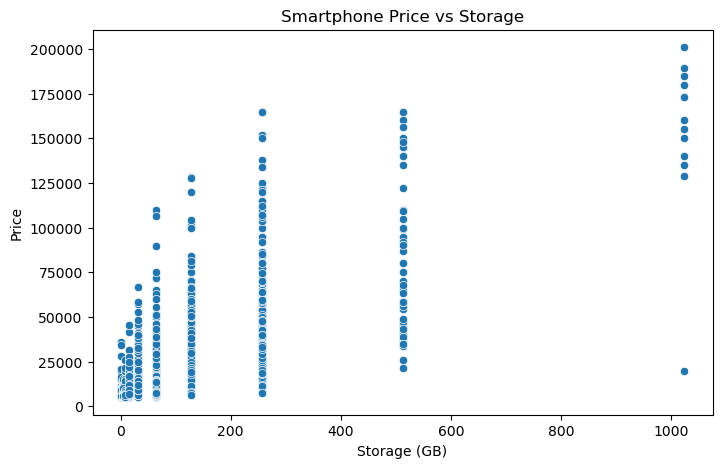

In [28]:
plt.figure(figsize = (8, 5))
sns.scatterplot(data = df, x = 'storage_gb', y = 'price_numeric')
plt.title('Smartphone Price vs Storage')
plt.xlabel('Storage (GB)')
plt.ylabel('Price')
plt.show()

#### ***Smartphone Price vs Battery***

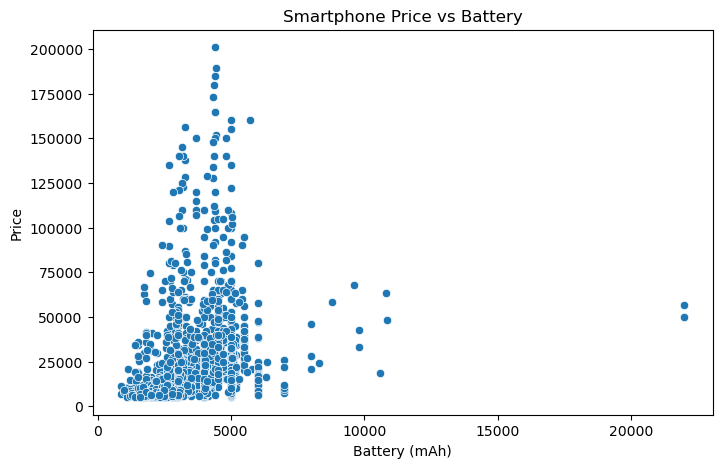

In [29]:
plt.figure(figsize = (8, 5))
sns.scatterplot(data = df, x = 'battery_mAh', y = 'price_numeric')
plt.title('Smartphone Price vs Battery')
plt.xlabel('Battery (mAh)')
plt.ylabel('Price')
plt.show()

#### ***Smartphone Price vs User Rating***

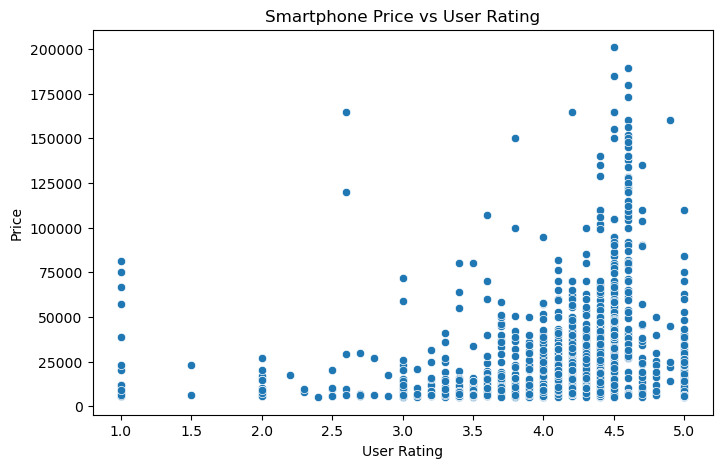

In [30]:
plt.figure(figsize = (8, 5))
sns.scatterplot(data = df, x = 'user_rating_numeric', y = 'price_numeric')
plt.title('Smartphone Price vs User Rating')
plt.xlabel('User Rating')
plt.ylabel('Price')
plt.show()

#### ***Correlation Analysis***

In [31]:
correlation_columns = feature_columns + ['price_numeric']
correlation_matrix = df[correlation_columns].corr()
correlation_matrix

,expert_rating,user_rating_numeric,ram_gb,storage_gb,battery_mAh,rear_camera_mp,front_camera_mp,display_size,price_numeric
expert_rating,1.000000,0.156396,0.306852,0.273826,0.068702,0.223954,0.216823,0.156305,0.376202
user_rating_numeric,0.156396,1.000000,0.232849,0.206680,0.179918,0.160940,0.189551,0.272529,0.180582
ram_gb,0.306852,0.232849,1.000000,0.739220,0.552440,0.646102,0.653256,0.666678,0.484392
storage_gb,0.273826,0.206680,0.739220,1.000000,0.369871,0.490822,0.475394,0.503452,0.698308
battery_mAh,0.068702,0.179918,0.552440,0.369871,1.000000,0.508105,0.375754,0.768585,0.077614
rear_camera_mp,0.223954,0.160940,0.646102,0.490822,0.508105,1.000000,0.520922,0.554146,0.208559
front_camera_mp,0.216823,0.189551,0.653256,0.475394,0.375754,0.520922,1.000000,0.476723,0.242716
display_size,0.156305,0.272529,0.666678,0.503452,0.768585,0.554146,0.476723,1.000000,0.246657
price_numeric,0.376202,0.180582,0.484392,0.698308,0.077614,0.208559,0.242716,0.246657,1.000000


#### ***Correlation Heatmap***

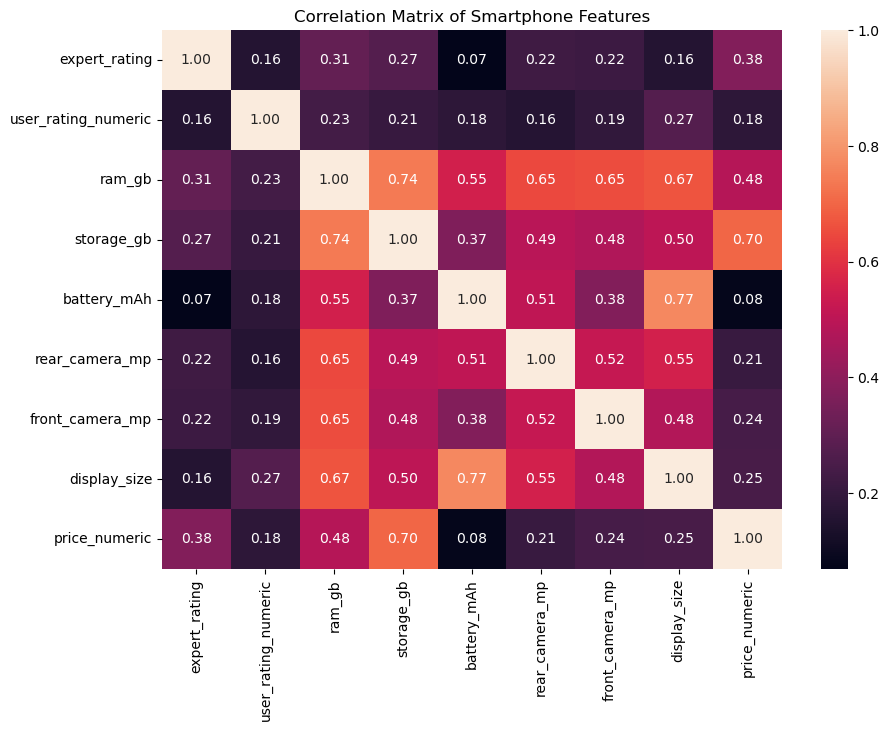

In [32]:
plt.figure(figsize = (10, 7))
sns.heatmap(correlation_matrix, annot = True, fmt = '.2f')
plt.title('Correlation Matrix of Smartphone Features')
plt.show()

## ***Build Baseline Model***

- Now we combine Task 3's modeling stage.

- The problem is a regression problem because the target variable, smartphone price, is numerical.
- We use Linear Regression as the baseline model.

#### ***Define Features and Target***

In [33]:
X = df[feature_columns]
y = df['price_numeric']

print('X Shape:', X.shape)
print('y Shape:', y.shape)

X Shape: (2256, 8)
y Shape: (2256,)


#### ***Train-Test Split***

In [34]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)
print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (1804, 8)
Testing data: (452, 8)


#### ***Train Linear Regression Model***

In [35]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[10399.24, 1533.71, 914.1 ,..., -124.52, -198.16, 898.23]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['expert_rating','user_rating_numeric','ram_gb',...,'rear_camera_mp', 'front_camera_mp','display_size']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-7.066e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


#### ***Generate Predictions***

In [36]:
y_pred = model.predict(x_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[ 9836.14226673 15033.3779608  12949.13162257 31589.88217821
 12215.13483901  6534.76659892 12730.72593293 32039.17742826
 14834.6208123  22472.44738612]


#### ***Model Evaluation***

In [37]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('MAE:', mae)
print('MSE:', mse)
print('RMSE:', rmse)
print('R2_Score:', r2)

MAE: 9734.277526940545
MSE: 214317424.1451786
RMSE: 14639.584152057687
R2_Score: 0.7032866485101676


#### ***Create Final Evaluation Table***

In [38]:
evalution = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2_Score'],
    'Value': [mae, mse, rmse, r2]
})

evalution

,Metric,Value
0,MAE,9.734278e+03
1,MSE,2.143174e+08
2,RMSE,1.463958e+04
3,R2_Score,7.032866e-01


#### ***Actual vs Predicted Prices***

In [39]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})
comparison.head(10)

,Actual Price,Predicted Price
0,8439,9836.142267
1,6499,15033.377961
2,12490,12949.131623
3,29999,31589.882178
4,13599,12215.134839
5,8990,6534.766599
6,20999,12730.725933
7,15990,32039.177428
8,7999,14834.620812
9,39999,22472.447386


#### ***Actual vs Predicted Visualization***

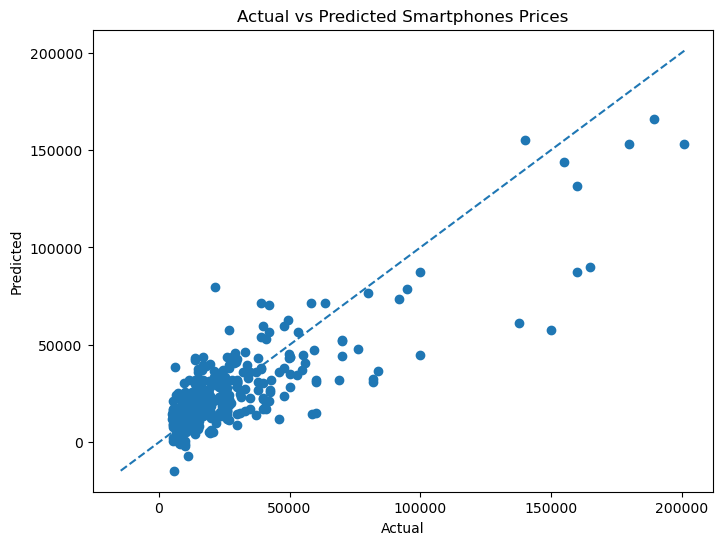

In [40]:
plt.figure(figsize = (8, 6))
plt.scatter(y_test, y_pred)
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle = '--')
plt.title('Actual vs Predicted Smartphones Prices')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

#### ***Prediction Error Analysis***

In [41]:
comparison['Error'] = (comparison['Actual Price'] - comparison['Predicted Price'])
comparison['Absolute Error'] = abs(comparison['Error'])
comparison.head()

,Actual Price,Predicted Price,Error,Absolute Error
0,8439,9836.142267,-1397.142267,1397.142267
1,6499,15033.377961,-8534.377961,8534.377961
2,12490,12949.131623,-459.131623,459.131623
3,29999,31589.882178,-1590.882178,1590.882178
4,13599,12215.134839,1383.865161,1383.865161


#### ***Error Distribution***

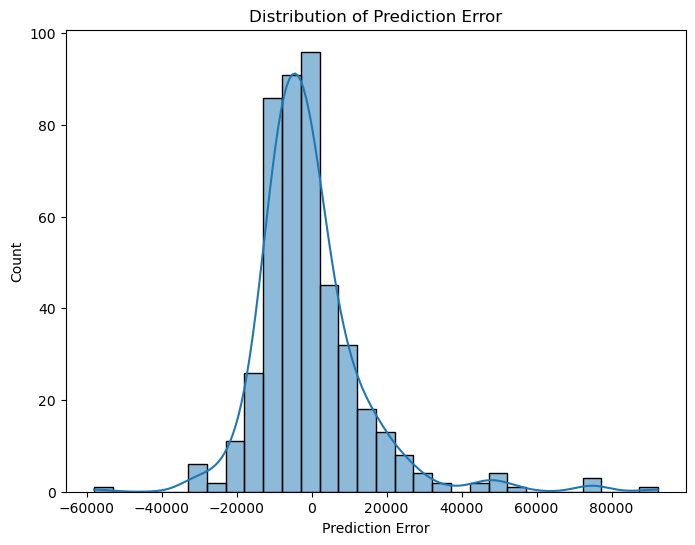

In [42]:
plt.figure(figsize = (8, 6))
sns.histplot(comparison['Error'], bins = 30, kde = True)
plt.title('Distribution of Prediction Error')
plt.xlabel('Prediction Error')
plt.ylabel('Count')
plt.show()

#### ***Largest Prediction Errors***

In [43]:
comparison.sort_values(by = "Absolute Error", ascending = False).head(10)

,Actual Price,Predicted Price,Error,Absolute Error
331,149999,57719.582428,92279.417572,92279.417572
265,137600,61002.483771,76597.516229,76597.516229
378,164999,90123.108664,74875.891336,74875.891336
293,159999,87280.891530,72718.108470,72718.108470
190,21499,79485.579866,-57986.579866,57986.579866
231,99999,44856.460695,55142.539305,55142.539305
420,81999,30758.505403,51240.494597,51240.494597
125,81900,32397.969663,49502.030337,49502.030337
417,200999,152887.401800,48111.598200,48111.598200
352,83999,36499.000959,47499.999041,47499.999041


#### ***Feature Coefficients***

In [44]:
coefficients = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by = "Coefficient", ascending = False)

,Feature,Coefficient
0,expert_rating,10399.238391
1,user_rating_numeric,1533.709662
2,ram_gb,914.096283
7,display_size,898.229948
3,storage_gb,136.804219
4,battery_mAh,-3.214406
5,rear_camera_mp,-124.523010
6,front_camera_mp,-198.160036


## ***Save Model Predictions***

In [45]:
comparison.to_csv("smartphone_price_predictions.csv", index = False)
print("Prediction results saved successfully.")

Prediction results saved successfully.


## ***Key Findings***

### ***Dataset***

- The prepared Smartphone Dataset contains 2256 records and 14 original columns. Data preparation removed duplicate records and handled missing values before further analysis.

### ***Price***

- The price distribution shows variation across different smartphone models, including budget and higher-priced devices.

### ***Specifications***

- The dataset contains smartphone specifications such as:
    - RAM
    - Storage
    - Battery
    - Cameras
    - Display
    - Ratings

* These features provide useful information for analyzing smartphone characteristics.

### ***Relationships***

- Scatter plots and the correlation matrix can be used to examine relationships between numerical smartphone features and price.
- However, correlation represents a linear relationship and does not necessarily imply causation.

### ***Model***

- A Linear Regression model was developed as a baseline for smartphone price prediction.
- The model was evaluated using:
    - MAE
    - MSE
    - RMSE
    - R² Score

* The actual metric values should be reported based on the results produced by the notebook.

## ***Model Limitations***

- The baseline model has several limitations.

#### **1. Linear Regression Assumption**

- Linear Regression assumes a linear relationship between features and smartphone price.
- Real-world smartphone pricing may involve nonlinear relationships.

#### **2. Limited Features**

- Only selected numerical features are used.
- Other factors may affect price, such as:
    - Brand
    - Processor
    - Display technology
    - Build quality
    - Launch date
    - Market demand
    - Product availability

#### **3. Categorical Information**

- Important categorical variables such as brand, processor, and operating system are not directly included in the baseline model.

#### **4. Text Information**

- The model does not use information from:
    - Reviews
    - Model names
    - Additional features

#### **5. Outliers**

- Very expensive smartphones may behave differently from budget and mid-range smartphones and can influence Linear Regression.

#### **6. Missing Specifications**

- Some smartphone specifications may be unavailable in the original data. Median imputation provides a practical solution for the baseline model, but it does not recover the actual missing specification.

#### **7. Baseline Model**

- Linear Regression is intentionally a simple baseline.
- More advanced algorithms may capture nonlinear relationships more effectively.

## **Future Improvements**

- Future versions of this project could include:
    - One-hot encoding for categorical variables
    - Brand-based features
    - Processor-based features
    - More detailed camera features
    - Advanced text analysis of reviews
    - Better outlier handling
    - Feature scaling where appropriate
    - Decision Tree Regression
    - Random Forest Regression
    - Gradient Boosting
    - Hyperparameter tuning
    - Cross-validation
    - Model comparison

* A future model can then be compared against the Linear Regression baseline.